In [1]:
import sys
sys.path.append('../')
from ArchVelo import *

In [3]:
import pickle
from scipy.sparse import csr_matrix

In [4]:
benchmark = False

In [5]:
num_comps = 10
n_jobs = 100

In [6]:
n_neighbors = 50
n_pcs=30

In [7]:
scv.settings.verbosity = 3
scv.settings.presenter_view = True
scv.set_figure_params('scvelo')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

In [8]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'+str(num_comps)+'_comps/'
os.makedirs(model_outdir, exist_ok = True)
arch_dir = 'modeling_results/archetypes/'

# Read in data

In [9]:
# load processed RNA
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')
# full processed atac for ArchVelo
adata_atac_raw = sc.read_h5ad(data_outdir+'adata_atac_raw.h5ad')
# aggregated atac for MultiVelo
adata_atac = sc.read_h5ad(data_outdir+'adata_atac.h5ad')

In [10]:
XC_raw = pd.read_csv(arch_dir+'cell_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])
S_raw = pd.read_csv(arch_dir+'peak_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])

In [11]:
nn_idx = np.loadtxt("seurat_wnn/nn_idx.txt", delimiter=',')
nn_dist = np.loadtxt("seurat_wnn/nn_dist.txt", delimiter=',')

In [12]:
peak_annotation = pd.read_csv('data/outs/our_peaks/nearest_genes_summits_correct_annot.csv', index_col = [0])#pd.read_csv('outs/peak_annotation.tsv', sep = '\t')

# Apply scVelo

In [13]:
rna_copy = adata_rna.copy()

In [14]:
scv.tl.recover_dynamics(rna_copy, var_names = rna_copy.var_names,n_jobs = -1)
scv.tl.velocity(rna_copy, mode='dynamical')
scv.tl.velocity_graph(rna_copy)
scv.tl.latent_time(rna_copy)


recovering dynamics (using 128/128 cores)


  0%|          | 0/930 [00:00<?, ?gene/s]

    finished (0:01:13) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x155549c2b220>>
Traceback (most recent call last):
  File "/mnt/home/mavdeeva/Software/VENVs/python3.8-env/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "/mnt/sw/nix/store/mpgyydv1wg7wwirp67ds6f2psq63s2p1-python-3.8.16-view/lib/python3.8/threading.py", line 1344, in enumerate
    with _active_limbo_lock:
KeyboardInterrupt: 


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'scVelo'}>

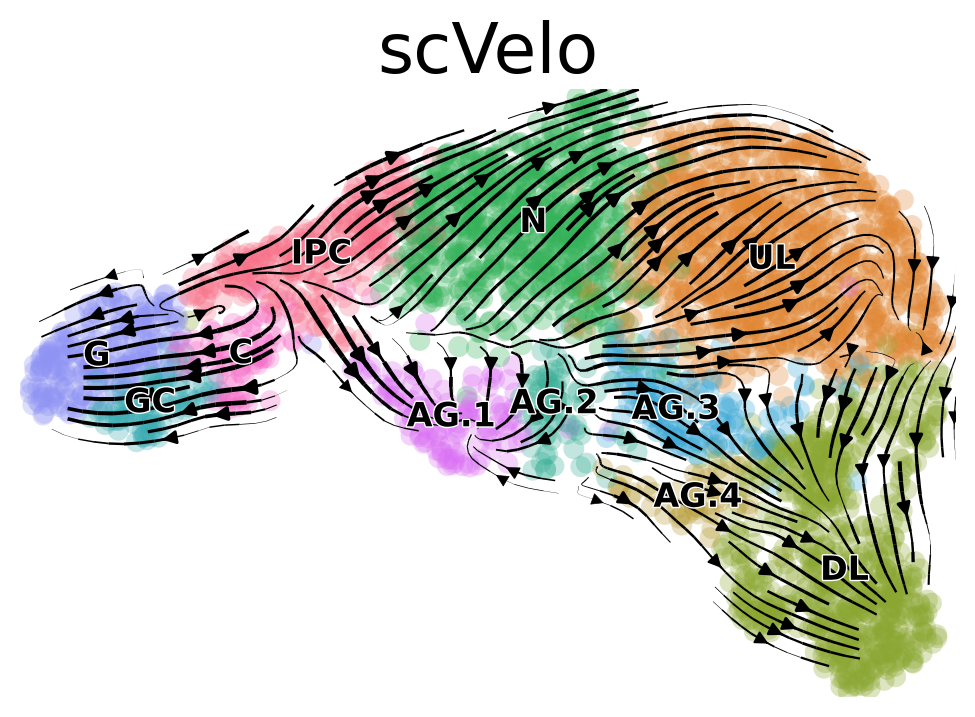

In [16]:
scv.pl.velocity_embedding_stream(rna_copy, color = 'cell_type_abbr',
                                 show = False,
                                title = 'scVelo',
                                fontsize = 25)

In [17]:
rna_copy.write(model_outdir+'scvelo_result.h5ad')

# Apply MultiVelo

In [18]:

adata_atac.layers['Mc'] = csr_matrix(np.array(adata_atac.layers['Mc'].todense()))

In [19]:
adata_result = mv.recover_dynamics_chrom(adata_rna, 
                                         adata_atac,
                                         n_jobs = n_jobs,
                                         n_neighbors = n_neighbors,
                                         n_pcs = n_pcs
                                        )

  0%|          | 0/930 [00:00<?, ?it/s]

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cell type abbr'}>

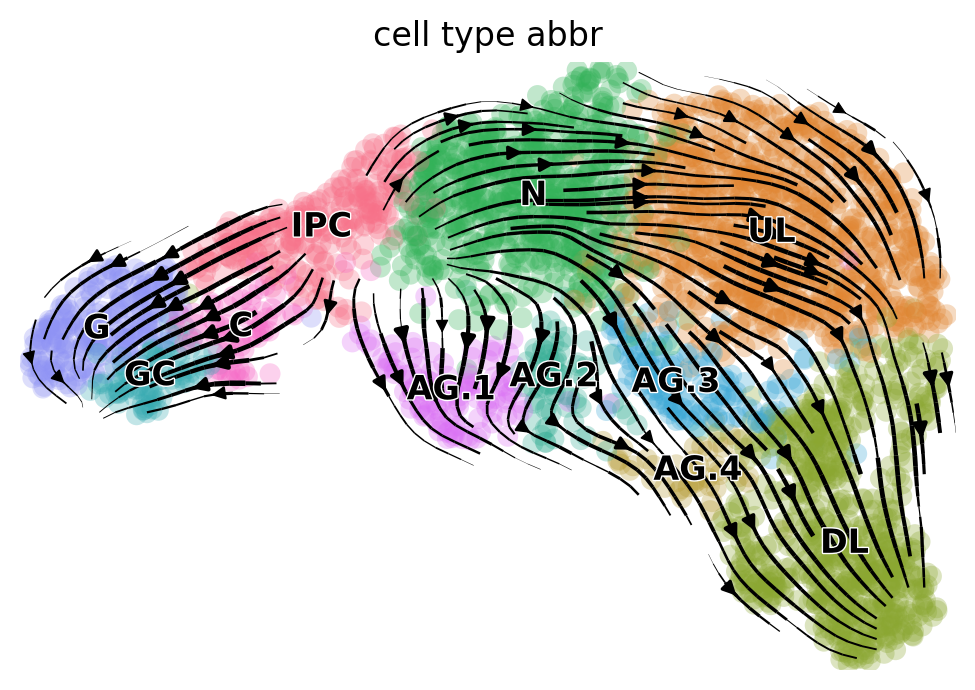

In [20]:
mv.velocity_graph(adata_result)
mv.latent_time(adata_result)
mv.velocity_embedding_stream(adata_result, 
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = False)

In [21]:
adata_result.write(model_outdir+'multivelo_result.h5ad')

In [22]:
if benchmark:
    for wc in np.linspace(0,1,11):
        adata_result = mv.recover_dynamics_chrom(adata_rna, 
                                             adata_atac,
                                             weight_c = wc,
                                             n_jobs = n_jobs,
                                             n_neighbors = n_neighbors,
                                             n_pcs = n_pcs
                                            )
        adata_result.write(model_outdir+'multivelo_result_weight_c_'+str(wc)+'.h5ad')

# Apply MultiVelo-AA

In [23]:
obs_index = adata_atac_raw.obs
conn = extract_wnn_connectivities(adata_atac_raw, 
                                      nn_idx, 
                                      nn_dist)

In [24]:
np.random.seed(57)
full_res_denoised = apply_MultiVelo_AA(adata_rna.copy(), 
                                       obs_index,
                                       conn,
                                       XC_raw,
                                       S_raw, 
                                       peak_annotation,
                                       nn_idx, 
                                       nn_dist,
                                       data_outdir = data_outdir,
                                       model_outdir = model_outdir,
                                       n_jobs = n_jobs,
                                       n_neighbors = n_neighbors,
                                       n_pcs = n_pcs
                               )
full_res_denoised.write(model_outdir+'multivelo_result_denoised_chrom.h5ad')

  0%|          | 0/930 [00:00<?, ?it/s]

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:06) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cell type abbr'}>

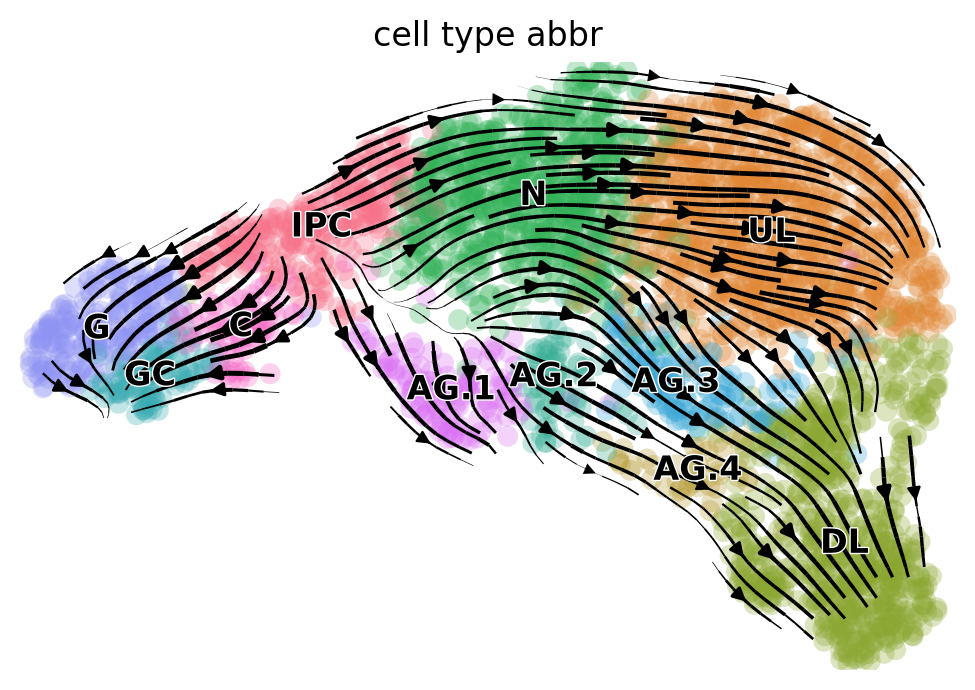

In [25]:
#mv.set_velocity_genes(full_res_denoised, likelihood_lower=0.02)
mv.velocity_graph(full_res_denoised)
mv.latent_time(full_res_denoised)
#sc.pl.umap(full_res_denoised, color = 'latent_time')
mv.velocity_embedding_stream(full_res_denoised, 
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = False)
# plt.title('')
# plt.savefig('figures/Multivelo_AA_results.png', dpi = 600)

In [26]:
# need to run
if benchmark:
    for wc in np.linspace(0,1,11):
        full_res_denoised = apply_MultiVelo_AA(adata_rna, 
                                               obs_index,
                                               conn,
                                               XC_raw,
                                               S_raw,
                                               peak_annotation,
                                               nn_idx, nn_dist,
                                               weight_c = wc, 
                                               data_outdir = data_outdir,
                                               model_outdir = model_outdir,
                                               n_jobs = n_jobs     
                               )
        full_res_denoised.write(model_outdir+'multivelo_result_denoised_chrom_weight_c_'+str(np.round(wc,1))+'.h5ad')



# Apply ArchVelo

In [13]:
adata_result = anndata.read_h5ad(model_outdir+'multivelo_result.h5ad')
full_res_denoised = anndata.read_h5ad(model_outdir+'multivelo_result_denoised_chrom.h5ad')

In [14]:
smooth_arch = sc.read_h5ad(model_outdir+'arches.h5ad')
gene_weights = pd.read_csv(model_outdir+'gene_weights.csv', index_col = [0])
    

In [15]:
# will run ArchVelo on top MultiVelo likelihood genes
top_lik = full_res_denoised.var['fit_likelihood'].sort_values(ascending = False).index
# save these genes
f = open(model_outdir+'top_lik.p', 'wb')
pickle.dump(top_lik, f)
f.close()

In [ ]:
if benchmark:
    wcs = [np.round(x, 1) for x in np.linspace(0,1,11)]
    for wc in wcs:
        av_pars = extract_ArchVelo_pars(adata_rna, 
                          full_res_denoised, 
                          smooth_arch,
                          gene_weights,
                          weight_c = wc, 
                          n_jobs = n_jobs)
        f = open(model_outdir+'archevelo_results_weight_c_'+str(np.round(wc,1))+'.p', 'wb')
        pickle.dump(av_pars, f)
        f.close()
    f = open(model_outdir+'archevelo_results_weight_c_0.3.p', 'rb')
    av_pars = pickle.load(f)
    f.close()
    min_c, max_c = extract_minmax(smooth_arch)
    avel = velocity_result(adata_rna, 
                      full_res_denoised,
                      gene_weights,
                       min_c, max_c,
                      av_pars)
else:
    avel = apply_ArchVelo(adata_rna, 
                   full_res_denoised,
                   smooth_arch,
                   gene_weights,
                   model_outdir)

### Add likelihood

In [90]:
avel.var['fit_likelihood'] = np.nan
for g in avel.var_names:    
    liks = calc_lik_ArchVelo(g,
                  adata_atac = adata_atac,
                  avel = avel)
    avel.var['fit_likelihood'].loc[g] = liks[0]

In [91]:
avel.var['fit_likelihood'].loc['Satb2']

3.6519451199481523

In [92]:
g = 'Satb2'

In [ ]:
plot = True

(3.6519451199481523, 2.14244306511656, 1.7045704408249787)

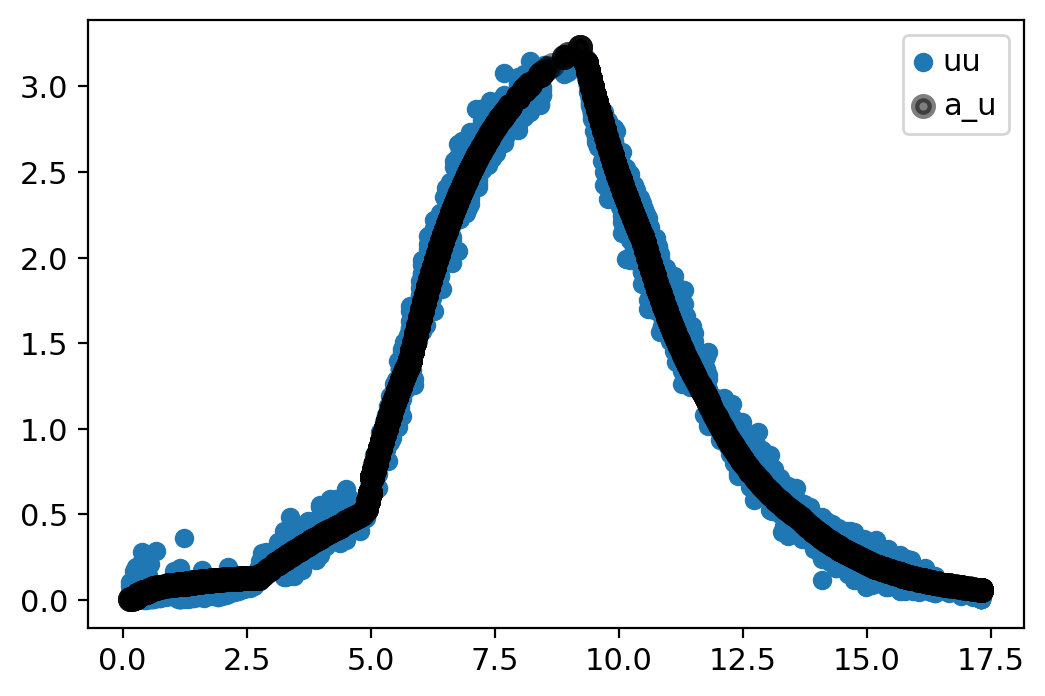

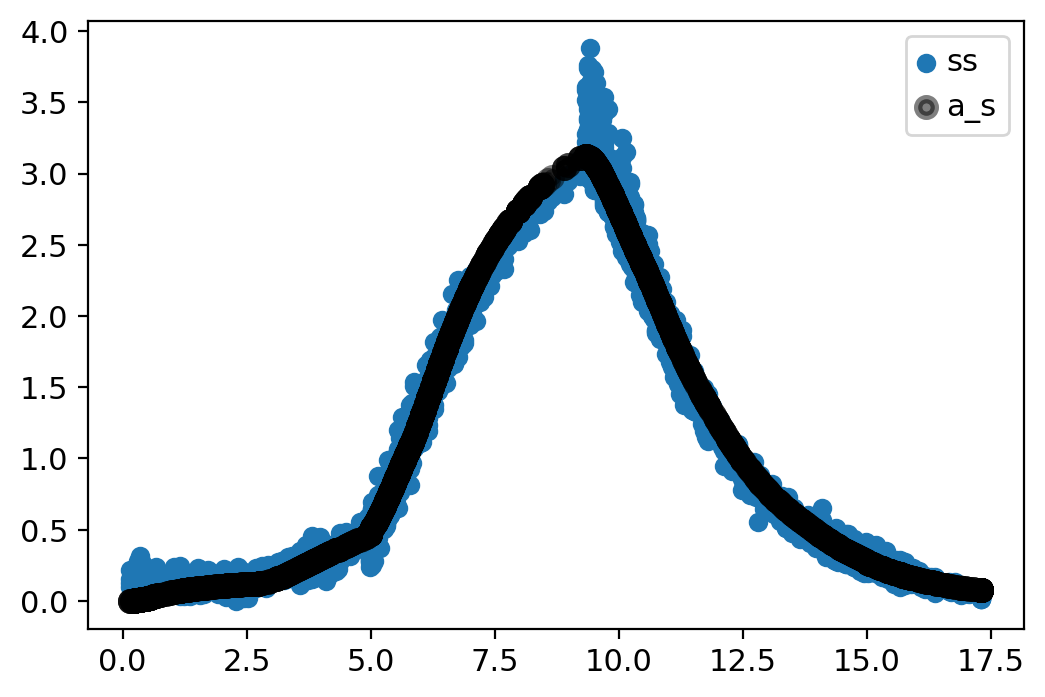

In [93]:
calc_lik_ArchVelo(g, 
                  adata_atac = adata_atac,
                  avel = avel, plot = plot,
                  multivelo_cells = True)

Num cells:  1411
3252


(1.8541290371459203, 1.4658378847787152, 1.2648936532472155)

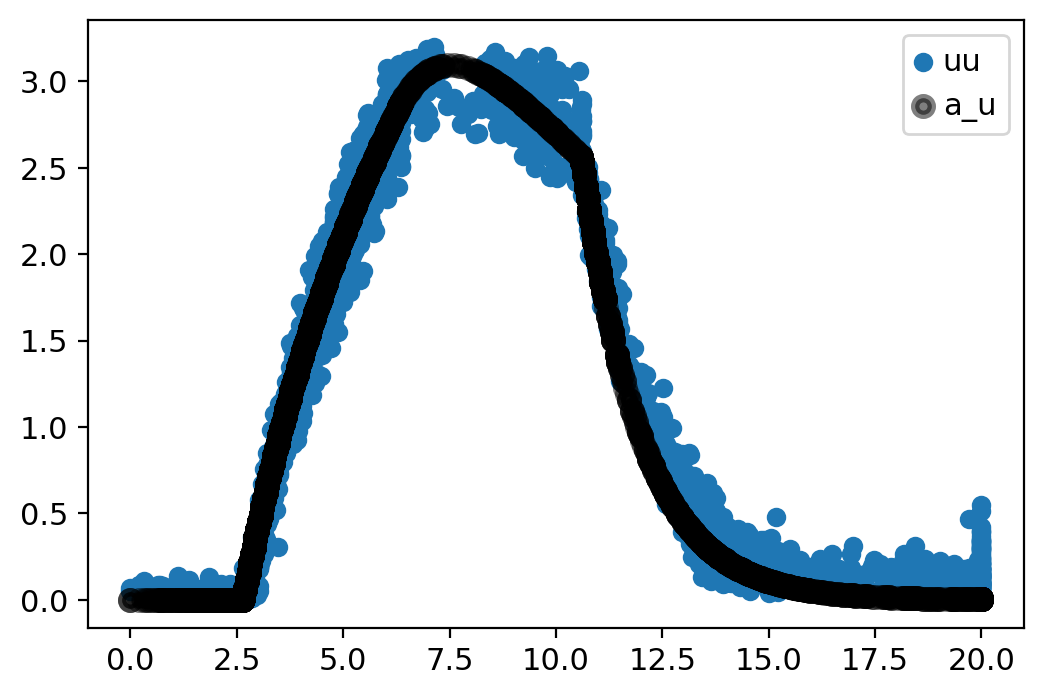

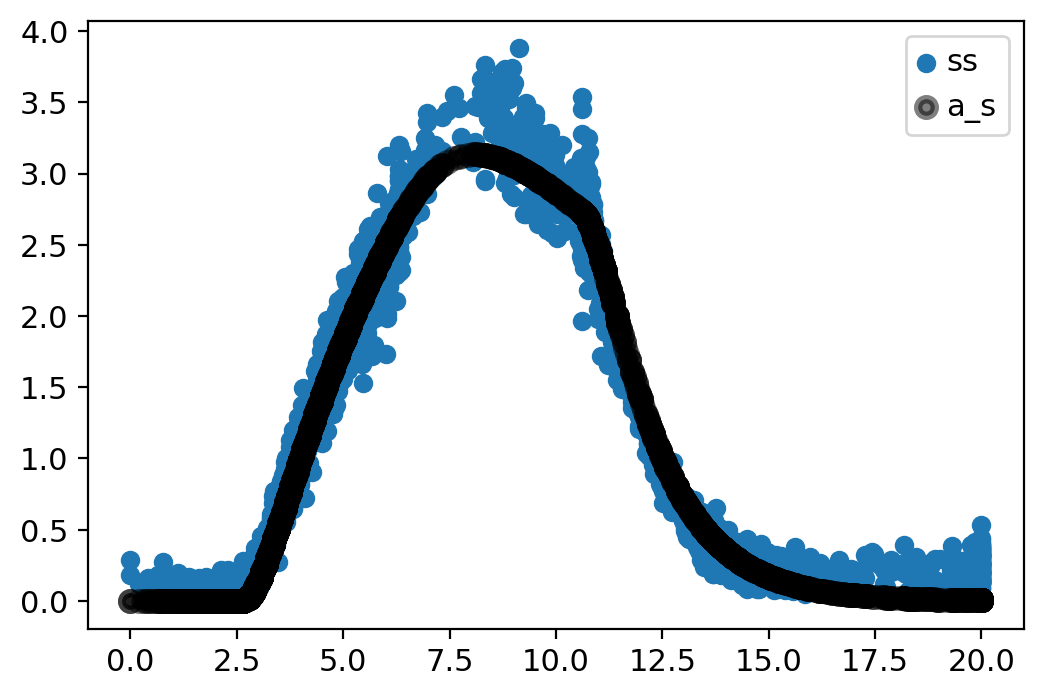

In [94]:
calc_lik_multivelo(g, 
                   model_to_use = adata_result,
                   plot = plot,
            )

In [95]:
lik_cutoff = 0.05
avel.var['velo_s_genes'] = (avel.var['fit_likelihood']>lik_cutoff)


## Write out 

In [96]:
avel.write(model_outdir+'archvelo_result.h5ad')

## Visualize

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:08) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing latent time using root_cells as prior
    finished (0:00:01) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


<Axes: title={'center': 'cell type abbr'}>

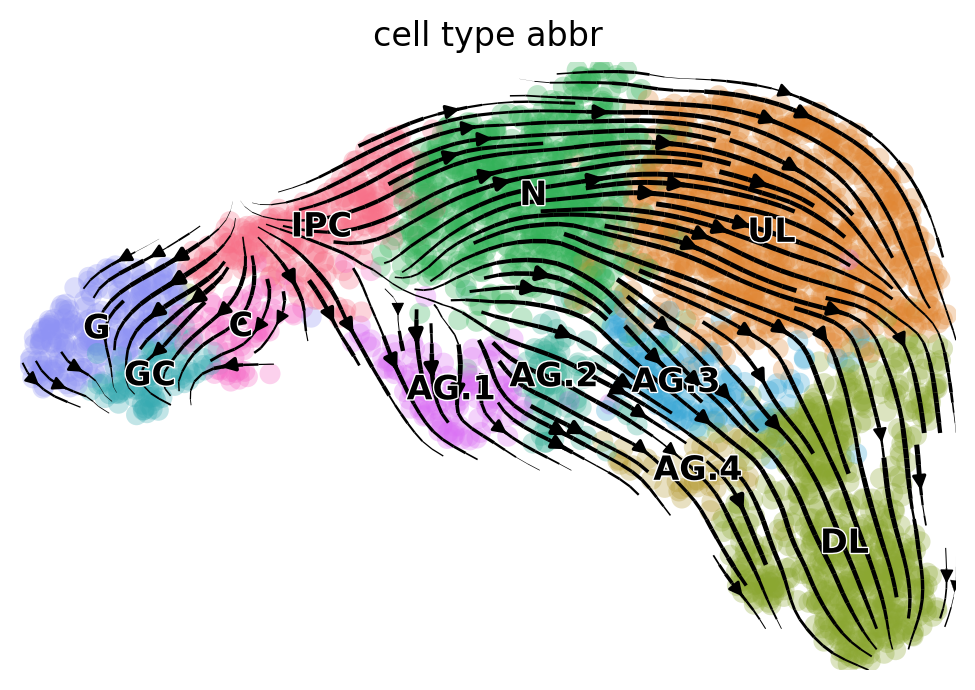

In [97]:
mv.velocity_graph(avel, vkey = 'velo_s')
mv.latent_time(avel)
mv.velocity_embedding_stream(avel, 
                             #vkey = 'velo_s',
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = False)